In [32]:
%cd /home/anw2067/visualnav-transformer/train
import torch
import yaml
from vint_train.data.vint_dataset import ViNT_Nymeria_Dataset
from PIL import Image
from vint_train.data.misc import XSensConstants
from tqdm import tqdm
from torch.utils.data import DataLoader
import numpy as np
from typing import Tuple
from torchvision.utils import save_image

import os
import torch
from torchvision.utils import draw_keypoints

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap
from scipy.spatial.transform import Rotation as R
from vint_train.data.misc import XSensConstants
from collections import defaultdict


/home/anw2067/visualnav-transformer/train


/scratch/anw2067/conda/envs/nomad_train2/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [33]:
config = "/home/anw2067/visualnav-transformer/train/logs/nomad-minimal/2025_12_09_11_24:nomad-minimal-proprioception-cat8-dinov3_unpool_3dposemb-proj-lr5e-4-pool_curr_obs-goaldraw/config.yaml"
nomad_config = yaml.safe_load(open(config, "r"))

save_dir="/home/anw2067/visualnav-transformer/outputs/vis_for_selecting_examples"


In [34]:

class VisualizationDataset(ViNT_Nymeria_Dataset):
    def __getitem__(self, i: int) -> Tuple[torch.Tensor]:
            """
            Args:
                i (int): index to ith datapoint
            Returns:
                Tuple of tensors containing the context, observation, goal, transformed context, transformed observation, transformed goal, distance label, and action label
                    obs_image (torch.Tensor): tensor of shape [3, H, W] containing the image of the robot's observation
                    goal_image (torch.Tensor): tensor of shape [3, H, W] containing the subgoal image 
                    dist_label (torch.Tensor): tensor of shape (1,) containing the distance labels from the observation to the goal
                    action_label (torch.Tensor): tensor of shape (5, 2) or (5, 4) (if training with angle) containing the action labels from the observation to the goal
                    which_dataset (torch.Tensor): index of the datapoint in the dataset [for identifying the dataset for visualization when using multiple datasets]
            """
            f_curr, curr_time, max_goal_dist = self.index_to_data[i]
            f_goal, goal_time, goal_is_negative = self._sample_goal(f_curr, curr_time, max_goal_dist)

            # Load images
            context = []
            # sample the last self.context_size times from interval [0, curr_time)
            context_times = list(
                range(
                    curr_time + -self.context_size * self.waypoint_spacing,
                    curr_time + 1,
                    self.waypoint_spacing,
                )
            )
            context = [(f_curr, t) for t in context_times]

            obs_images = torch.stack([
                self._load_image(f, t) for f, t in context # these are C, H, W tensors
            ], dim=0)
            obs_image_transformed = self.transform(obs_images)

            # Load goal image
            goal_image = self._load_image(f_goal, goal_time) # this is already a C, H, W tensor
            goal_image_transformed = self.transform(goal_image)

            # Load other trajectory data
            curr_traj_data = self._get_trajectory(f_curr)
            curr_traj_len = len(curr_traj_data[self.traj_len_key])
            assert curr_time < curr_traj_len, f"{curr_time} and {curr_traj_len}"

            # always return goal_image_coords
            target_idx = goal_time - curr_time + (curr_traj_data["image_projection_matrix"].shape[1] // 2)
            image_coords = curr_traj_data["image_projection_matrix"][curr_time, target_idx, :] # K, 2
            
            # Swap x and y, and invert the new y axis
            rotated_image_coords = torch.empty_like(image_coords)
            rotated_image_coords[:, 0] = 2880 - 1 - image_coords[:, 1]  # new x
            rotated_image_coords[:, 1] = image_coords[:, 0]  # new y
            # keep the -1 elements
            rotated_image_coords = rotated_image_coords / 2880 * self.image_size[0]
            rotated_image_coords[image_coords == -1] = -1
            image_coords = rotated_image_coords

            ret_dict = {
                "dataset_index": i,
                "dataset_track": f_curr,
                "dataset_track_index": curr_time,
                "obs_image_transformed": obs_image_transformed.type(torch.float32),
                "goal_image_transformed": goal_image_transformed.type(torch.float32),
                "obs_images": obs_images.type(torch.float32),
                "goal_image": goal_image.type(torch.float32),
                "goal_obs": goal_image.type(torch.float32), # always the observation at goal time, goal_image can vary with goal_type
                "goal_obs_transformed": goal_image_transformed.type(torch.float32),
                "goal_image_coords": torch.as_tensor(image_coords, dtype=torch.float32),
            }
            
            if "xsens_offsets" in curr_traj_data:
                ret_dict["xsens_offsets"] = torch.as_tensor(curr_traj_data["xsens_offsets"], dtype=torch.float32)
            
            if self.goal_type in ["2d", "2d5050", "draw"]:
                if self.waypoint_mask_prob is "uniform":
                    do_mask = torch.rand(1) < 0.5
                    if do_mask:
                        num_mask = np.random.randint(1, 5)
                        masked_indices = np.random.choice(4, num_mask, replace=False)
                        for idx, part_idx in enumerate([XSensConstants.part_names.index(part_name) for part_name in ["Pelvis","Head", "R_Hand", "L_Hand"]]):
                            if idx in masked_indices:
                                ret_dict["goal_image_coords"][idx] = torch.tensor([-1, -1])
                        image_coords = ret_dict["goal_image_coords"]
                
            if self.goal_type == "point": # late fusion semi "cheat" model
                pass
            elif self.goal_type in ["2d", "2d5050"]:
                ret_dict["goal_image_transformed"] = obs_image_transformed[-1]
                ret_dict["goal_image"] = obs_images[-1]
            elif self.goal_type == "draw":
                untransformed_current_obs = obs_images[-1]
                key_point_image_coords = torch.stack(
                    [image_coords[XSensConstants.part_names.index(part_name)] for part_name in ["Pelvis","Head", "R_Hand", "L_Hand"]]
                , dim=0) # 4, 2
                for index, color in zip(range(len(key_point_image_coords)), ["red", "green", "blue", "yellow"]):
                    if all(key_point_image_coords[index] == -1): continue
                    points = key_point_image_coords[index:index+1, None, :]
                    untransformed_current_obs = draw_keypoints(untransformed_current_obs, points, colors=color, radius=4)
                ret_dict["goal_image_transformed"] = self.transform(untransformed_current_obs)
                ret_dict["goal_image"] = untransformed_current_obs
            return ret_dict

def get_nymeria_dataset(config, context_size=15-1, split="test", goal_timestep_offset=None):
    """
    Utility for building the Nymeria dataset for CEM planning.
    Notably, does not normalize loaded deltas.
    """
    data_config = config["datasets"]["nymeria"]
    
    if "waypoint_spacing" not in data_config:
        data_config["waypoint_spacing"] = 1
    if "negative_goals" not in data_config:
        data_config["negative_goals"] = False
    if "end_slack" not in data_config:
        data_config["end_slack"] = 0
    if "goals_per_obs" not in data_config:
        data_config["goals_per_obs"] = 1
    if goal_timestep_offset is not None:
        config['distance']['min_dist_cat'] = goal_timestep_offset
        config['distance']['max_dist_cat'] = goal_timestep_offset

    ### EVAL ONLY -- DO NOT NORMALIZE THE DELTAS
    config["normalize"] = False
    
    # transform = ([
    #     transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    # ])
    # transform = transforms.Compose(transform)
    transform = torch.nn.Identity()
    
    if context_size is None:
        context_size = config["context_size"]
    
    dataset = VisualizationDataset(
        data_folder=data_config["data_folder"],
        data_split_folder=data_config[split],
        dataset_name="nymeria",
        image_size=config["image_size"],
        transform=transform,
        waypoint_spacing=data_config["waypoint_spacing"],
        min_dist_cat=config["distance"]["min_dist_cat"],
        max_dist_cat=config["distance"]["max_dist_cat"],
        min_action_distance=config["action"]["min_dist_cat"],
        max_action_distance=config["action"]["max_dist_cat"],
        negative_goals=data_config["negative_goals"],
        len_traj_pred=config["len_traj_pred"],
        context_size=context_size,
        goal_type=config.get("goal_type", None),
        preserve_pose_up_down=data_config.get("preserve_pose_up_down", False),
        end_slack=data_config["end_slack"],
        goals_per_obs=data_config["goals_per_obs"],
        normalize=config["normalize"],
        gaussian_normalization_stats_path=data_config["gaussian_normalization_stats_path"],
    )
    return dataset

<>:73: SyntaxWarning: "is" with a literal. Did you mean "=="?
<>:73: SyntaxWarning: "is" with a literal. Did you mean "=="?
/tmp/ipykernel_2488497/2521559699.py:73: SyntaxWarning: "is" with a literal. Did you mean "=="?
  if self.waypoint_mask_prob is "uniform":


In [35]:
def plot_track_data(data, title=None, save_name=None, figsize=None):
    """
    Plot a list of integers (0-4) as a 2D image with gradient colors.
    
    Args:
        data: List or array of integers between 0 and 4 inclusive
        title: Optional title for the plot. If None, uses default title with length
        figsize: Optional tuple for figure size. If None, uses default sizing
    """
    data_array = np.array(data)
    
    # Determine a good shape for the 2D visualization
    # Try to make it roughly square or slightly wider
    length = len(data_array)
    # Find a good width (e.g., around sqrt of length, or a reasonable width)
    width = int(np.ceil(np.sqrt(length)))
    height = int(np.ceil(length / width))
    
    # Pad the array to fit the 2D shape
    padded_length = width * height
    padded_data = np.pad(data_array, (0, padded_length - length), mode='constant', constant_values=-1)
    
    # Reshape to 2D
    image_data = padded_data.reshape(height, width)
    
    # Create a custom gradient colormap: white -> light blue -> dark blue
    colors = ['#FFFFFF', '#87CEEB', '#4682B4', '#1E3A8A', '#000080']  # White -> Light blue -> Steel blue -> Dark blue -> Very dark blue
    n_bins = 256
    cmap = LinearSegmentedColormap.from_list('custom_gradient', colors, N=n_bins)
    
    # Normalize values 0-4 for the gradient
    # Mask out padding values (-1) by setting them to NaN
    masked_image = image_data.astype(float)
    masked_image[masked_image == -1] = np.nan
    
    # Create the plot
    if figsize is None:
        figsize = (15, max(5, height * 0.3))
    plt.figure(figsize=figsize)
    im = plt.imshow(masked_image, cmap=cmap, vmin=0, vmax=4, aspect='auto', interpolation='nearest')
    plt.colorbar(im, label='Value', ticks=[0, 1, 2, 3, 4])
    
    if title is None:
        title = f'Visualization (length: {length})'
        
    plt.title(title)
    plt.xlabel('Index (width)')
    plt.ylabel('Index (height)')
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, f'{save_name}.png'))
    plt.show()
    
    # Also print some statistics
    print(f"Length: {length}")
    print(f"Shape: {height} x {width}")
    print(f"Value counts: {dict(zip(*np.unique(data_array, return_counts=True)))}")

In [ ]:
def save_images(batch, save_path):
    obs_images = batch["obs_images"] # T, 3, H, W
    goal_image = batch["goal_image"][None] # 1, 3, H, W
    goal_obs = batch["goal_obs"][None] # 1, 3, H, W

    zeros = torch.zeros_like(goal_image)
    # image_list = [obs_images, zeros, goal_image, zeros, goal_obs]
    image_list = [obs_images, goal_image, goal_obs]
    images = torch.cat(image_list, dim=0)
    save_image(images, save_path, nrow=images.shape[0])
    
def sample_images(dataset, save_dir, vis_stack, index_stack, n_samples=10):
    vis_sum = vis_stack.sum(dim=1) # N, [0,4] of how many are visible
    
    # Group indices by vis_sum value
    selected_indices = []
    for vis_value in range(5):  # 0, 1, 2, 3, 4
        # Find all indices with this vis_sum value
        mask = (vis_sum == vis_value)
        indices_with_value = torch.where(mask)[0].tolist()
        
        # Select 20 indices (or all if fewer than 20)
        n_samples = min(n_samples, len(indices_with_value))
        if n_samples > 0:
            selected = np.random.choice(indices_with_value, size=n_samples, replace=False)
            selected_indices.extend(selected.tolist())
            print(f"vis_sum={vis_value}: selected {n_samples} indices (total available: {len(indices_with_value)})")
    
    # Sort to maintain order
    selected_indices = sorted(selected_indices)
    
    # Load and save images for selected indices
    for idx in selected_indices:
        dataset_idx = index_stack[idx].item()
        batch = dataset[dataset_idx]
        
        # Create save path
        track = batch["dataset_track"]
        track_idx = batch["dataset_track_index"]
        os.makedirs(os.path.join(save_dir, track, f"vis_sum_{int(vis_sum[idx].item())}"), exist_ok=True)
        save_path = os.path.join(save_dir, track, f"vis_sum_{int(vis_sum[idx].item())}", f"{dataset_idx:06d}-{track}-{track_idx:06d}.png")
        
        save_images(batch, save_path)
    
    return selected_indices
    
    

In [37]:
from torch.utils.data import Sampler

class EveryNthSampler(Sampler):
    """
    Sampler that only selects every nth example from a dataset.
    
    Args:
        dataset: The dataset to sample from
        n: Sample every nth example (default: 10)
    """
    def __init__(self, dataset, n=10):
        self.dataset = dataset
        self.n = n
        self.indices = list(range(0, len(dataset), n))
    
    def __iter__(self):
        return iter(self.indices)
    
    def __len__(self):
        return len(self.indices)

  0%|          | 419/102359 [00:03<08:33, 198.65it/s]

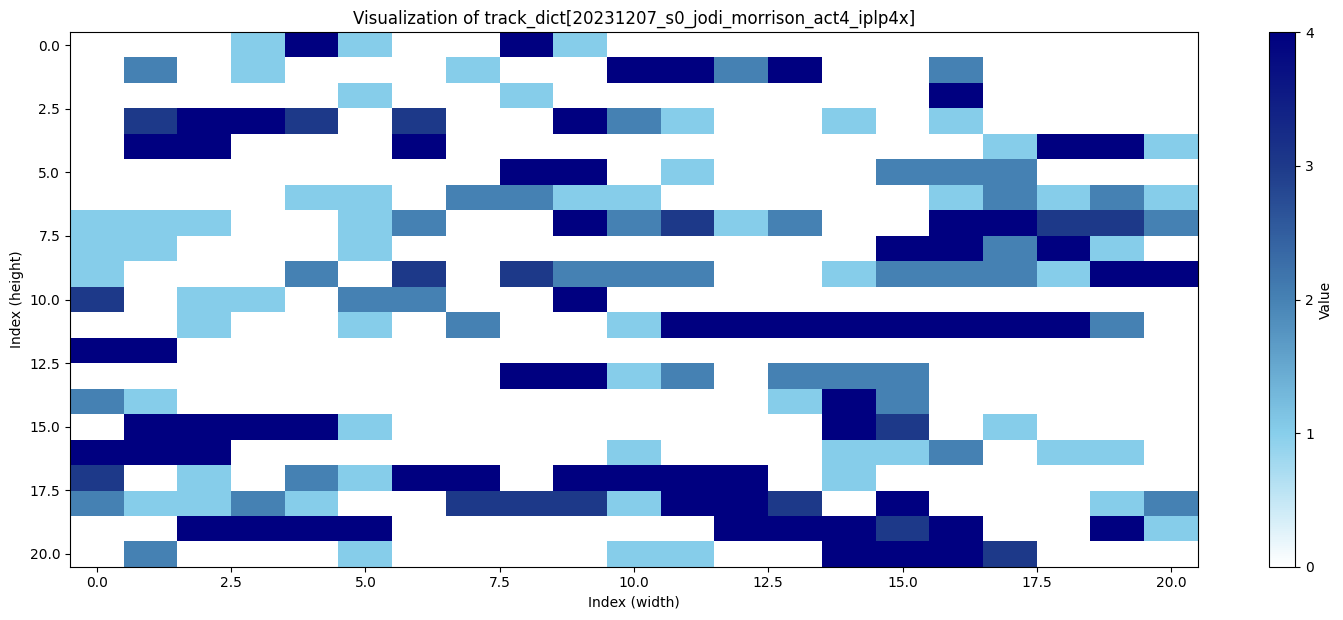

Length: 439
Shape: 21 x 21
Value counts: {0.0: 257, 1.0: 59, 2.0: 39, 3.0: 17, 4.0: 67}
vis_sum=0: selected 20 indices (total available: 257)
vis_sum=1: selected 20 indices (total available: 59)
vis_sum=2: selected 20 indices (total available: 39)
vis_sum=3: selected 17 indices (total available: 17)
vis_sum=4: selected 20 indices (total available: 67)


  1%|          | 905/102359 [00:30<10:04, 167.81it/s] 

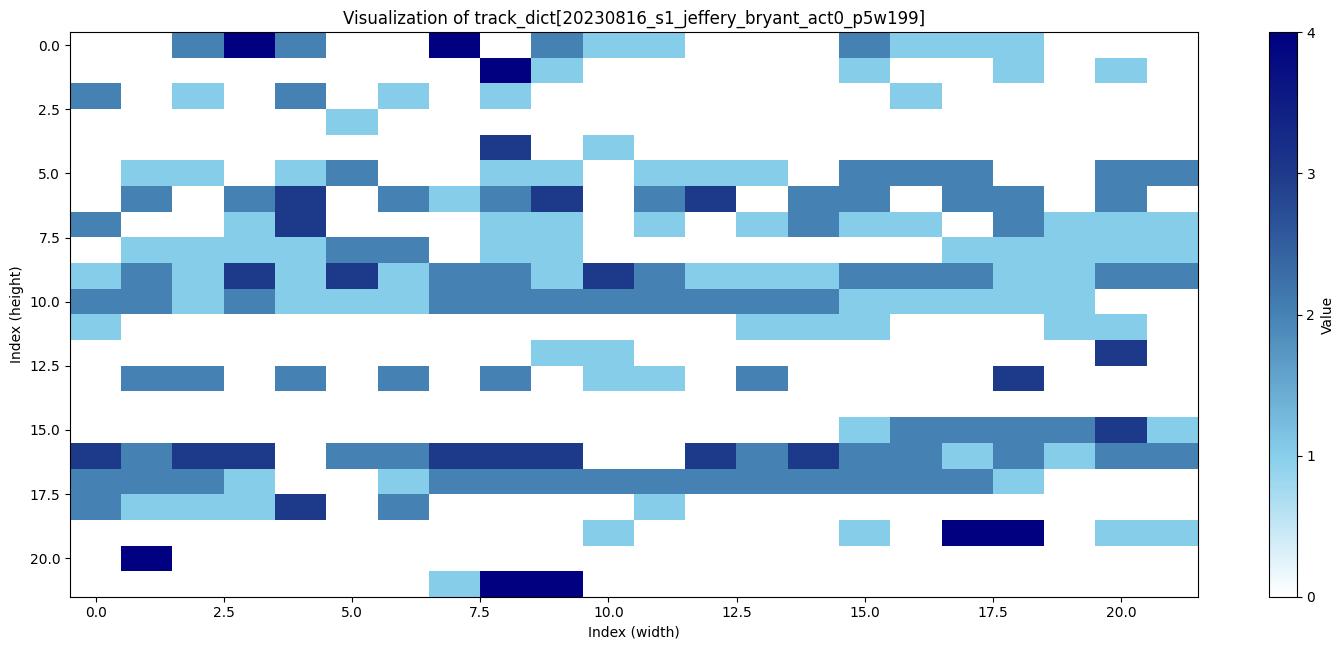

Length: 475
Shape: 22 x 22
Value counts: {0.0: 275, 1.0: 90, 2.0: 82, 3.0: 20, 4.0: 8}
vis_sum=0: selected 20 indices (total available: 275)
vis_sum=1: selected 20 indices (total available: 90)
vis_sum=2: selected 20 indices (total available: 82)
vis_sum=3: selected 20 indices (total available: 20)
vis_sum=4: selected 8 indices (total available: 8)


  1%|▏         | 1497/102359 [00:52<14:13, 118.15it/s] 

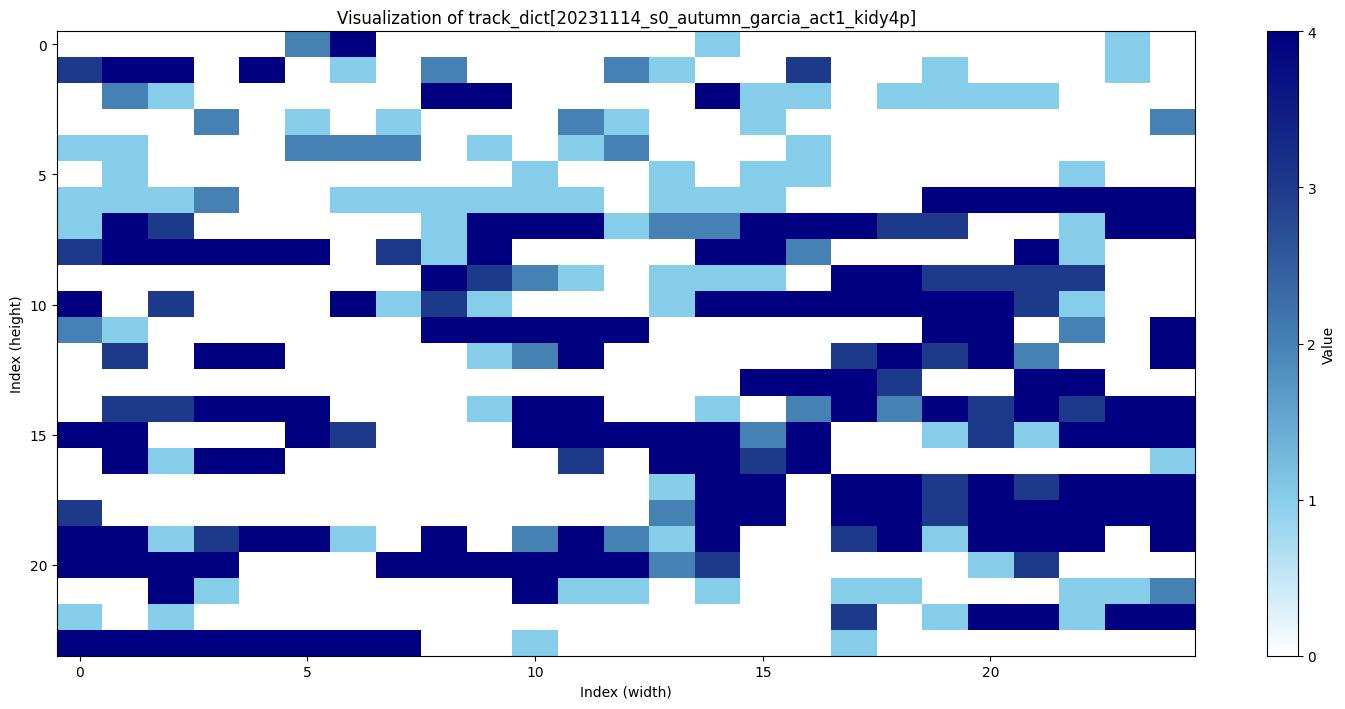

Length: 597
Shape: 24 x 25
Value counts: {0.0: 308, 1.0: 82, 2.0: 28, 3.0: 36, 4.0: 143}
vis_sum=0: selected 20 indices (total available: 308)
vis_sum=1: selected 20 indices (total available: 82)
vis_sum=2: selected 20 indices (total available: 28)
vis_sum=3: selected 20 indices (total available: 36)
vis_sum=4: selected 20 indices (total available: 143)


  2%|▏         | 1975/102359 [01:14<08:07, 205.91it/s] 

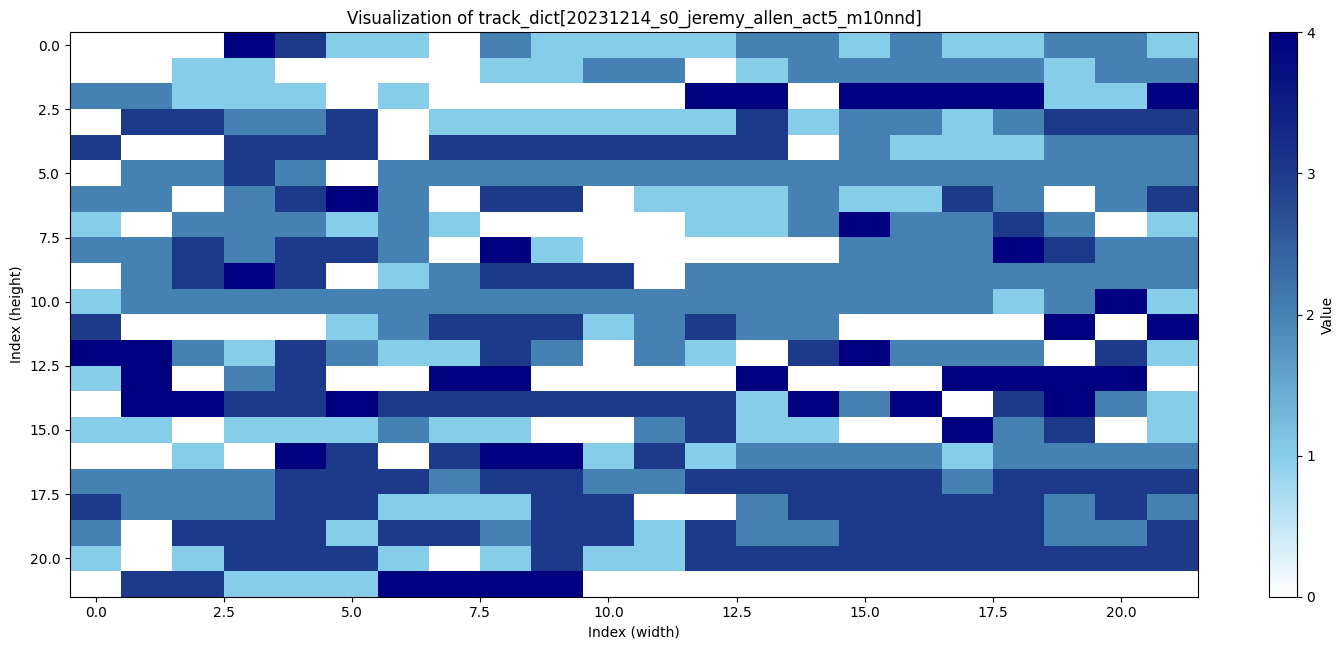

Length: 473
Shape: 22 x 22
Value counts: {0.0: 87, 1.0: 87, 2.0: 144, 3.0: 114, 4.0: 41}
vis_sum=0: selected 20 indices (total available: 87)
vis_sum=1: selected 20 indices (total available: 87)
vis_sum=2: selected 20 indices (total available: 144)
vis_sum=3: selected 20 indices (total available: 114)
vis_sum=4: selected 20 indices (total available: 41)


  2%|▏         | 1984/102359 [01:20<1:08:03, 24.58it/s]
/tmp/ipykernel_2488497/2521559699.py:73: SyntaxWarning: "is" with a literal. Did you mean "=="?
  if self.waypoint_mask_prob is "uniform":
/tmp/ipykernel_2488497/2521559699.py:73: SyntaxWarning: "is" with a literal. Did you mean "=="?
  if self.waypoint_mask_prob is "uniform":
/tmp/ipykernel_2488497/2521559699.py:73: SyntaxWarning: "is" with a literal. Did you mean "=="?
  if self.waypoint_mask_prob is "uniform":
/tmp/ipykernel_2488497/2521559699.py:73: SyntaxWarning: "is" with a literal. Did you mean "=="?
  if self.waypoint_mask_prob is "uniform":
/tmp/ipykernel_2488497/2521559699.py:73: SyntaxWarning: "is" with a literal. Did you mean "=="?
  if self.waypoint_mask_prob is "uniform":
/tmp/ipykernel_2488497/2521559699.py:73: SyntaxWarning: "is" with a literal. Did you mean "=="?
  if self.waypoint_mask_prob is "uniform":


KeyboardInterrupt: 

In [ ]:
from collections import defaultdict

dataset = get_nymeria_dataset(nomad_config, context_size=5, goal_timestep_offset=8)
sampler = EveryNthSampler(dataset, n=8)
dataloader = DataLoader(dataset, batch_size=1, shuffle=False, num_workers=12, sampler=sampler)

track_num = 0
prev_track = None
for batch in tqdm(dataloader):
    idx = batch["dataset_index"][0].item()
    track = batch["dataset_track"][0]
    track_idx = batch["dataset_track_index"][0].item()
    
    if not prev_track:
        prev_track = track
        vis_stack = torch.empty(0, 4)
        index_stack = torch.empty(0, dtype=torch.int64)
    elif prev_track != track:
        plot_track_data(vis_stack.sum(dim=1).tolist(), title=f'Visualization of track_dict[{prev_track}]', save_name=f"{track_num:03d}-{prev_track}")
        torch.save({"vis": vis_stack, "index": index_stack}, os.path.join(save_dir, f'{track_num:03d}-{prev_track}.pt'))
        sample_images(dataset, save_dir, vis_stack, index_stack, n_samples=4)
        prev_track = track
        vis_stack = torch.empty(0, 4)
        index_stack = torch.empty(0, dtype=torch.int64)
        track_num += 1
    
    goal_image_coords = batch["goal_image_coords"] # 1, 23, 2
    find_count = torch.zeros(1, 4)
    for part_index, part in enumerate(["Pelvis", "Head", "R_Hand", "L_Hand"]):
        index = XSensConstants.part_names.index(part)
        if all(goal_image_coords[0, index] != -1):
            find_count[0, part_index] = 1
    
    vis_stack = torch.cat([vis_stack, find_count], dim=0)
    index_stack = torch.cat([index_stack, torch.tensor([idx], dtype=torch.int64)], dim=0)
    
    # print(f"idx: {idx.item()} track: {track.item()} track_idx: {track_idx.item()} find_count: {find_count}")